In [ ]:
!git clone https://github.com/cuilimeng/CrackForest-dataset.git

fatal: destination path 'CrackForest-dataset' already exists and is not an empty directory.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import os

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def unet_model(input_shape=(256, 256, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    b1 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    b1 = layers.Conv2D(256, 3, activation='relu', padding='same')(b1)

    # Decoder
    u1 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(b1)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(u1)
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(c3)

    u2 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u2)
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(c4)

    outputs = layers.Conv2D(num_classes, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model

unet = unet_model()
unet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 256, 256,  │      1,792 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_22[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_23[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 128, 128,  │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_24[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 64, 64,    │    295,168 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 64, 64,    │    590,080 │ conv2d_26[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 128, 128,  │    131,200 │ conv2d_27[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 128, 128,  │    295,040 │ concatenate_4[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 128, 128,  │    147,584 │ conv2d_28[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 256, 256,  │     32,832 │ conv2d_29[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 256, 256,  │     73,792 │ concatenate_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_30[0][0] 

 Total params: 1,862,849 (7.11 MB)

 Trainable params: 1,862,849 (7.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os
image_dir = "/content/CrackForest-dataset/image"
mask_dir = "/content/CrackForest-dataset/mask"

In [ ]:
image_dir = "/content/CrackForest-dataset/image"
mask_dir = "/content/CrackForest-dataset/groundTruth"

In [ ]:
import os
print("Images:", len(os.listdir(image_dir)))
print("Masks:", len(os.listdir(mask_dir)))

Images: 156
Masks: 118


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T

class CrackDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

In [ ]:
image_dir = "/content/CrackForest-dataset/image"
mask_dir = "/content/CrackForest-dataset/groundTruth"

transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])

dataset = CrackDataset(image_dir, mask_dir, transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4)

In [ ]:
IMG_SIZE = (256,256)

def load_image(image_path, mask_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE)
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask

def create_dataset(image_paths, mask_paths, batch_size=8):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

In [ ]:
common = sorted(list(image_names & mask_names))

image_files = [os.path.join(IMAGE_DIR, f"{name}.jpg") for name in common]
mask_files = [os.path.join(MASK_DIR, f"{name}.jpg") for name in common]

In [ ]:
split = int(0.8 * len(image_files))
train_img, val_img = image_files[:split], image_files[split:]
train_mask, val_mask = mask_files[:split], mask_files[split:]

In [ ]:
import tensorflow as tf

# Convert all image & mask paths to strings explicitly
train_img = [str(p) for p in train_img]
train_mask = [str(p) for p in train_mask]
val_img = [str(p) for p in val_img]
val_mask = [str(p) for p in val_mask]

In [ ]:
def load_image(image_path, mask_path):
    image_path = tf.cast(image_path, tf.string)
    mask_path = tf.cast(mask_path, tf.string)

    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (256, 256))
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_jpeg(mask, channels=1)
    mask = tf.image.resize(mask, (256, 256))
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


# Build TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_img, train_mask))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(8).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_img, val_mask))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(8).prefetch(tf.data.AUTOTUNE)


In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

# Paths
image_dir = "/content/CrackForest-dataset/image"
mask_dir = "/content/CrackForest-dataset/groundTruth"

# Params
IMG_SIZE = (256, 256)

# Step 1 — Load images
image_files = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpg')])

# Step 2 — Load corresponding masks
mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.mat')])

images = []
masks = []

for img_path, mask_path in zip(image_files, mask_files):
    # Load image
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0

    # Load mask from .mat file
    mat = loadmat(mask_path)
    # The mask variable is usually under 'groundTruth' → [0][0][1] (depends on CrackForest)
    mask = mat['groundTruth'][0][0][1] if 'groundTruth' in mat else list(mat.values())[-1]
    mask = cv2.resize(mask, IMG_SIZE)
    mask = np.expand_dims(mask, axis=-1)
    mask = mask / np.max(mask)

    images.append(img)
    masks.append(mask)

images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)

print("Loaded images:", images.shape)
print("Loaded masks:", masks.shape)

# Step 3 — Split dataset
train_img, val_img, train_mask, val_mask = train_test_split(images, masks, test_size=0.2, random_state=42)

# Step 4 — TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_img, train_mask)).batch(8).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((val_img, val_mask)).batch(8).prefetch(tf.data.AUTOTUNE)

# Step 5 — Compile and train your UNet model
unet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = unet.fit(train_ds, validation_data=val_ds, epochs=50)


Loaded images: (118, 256, 256, 3)
Loaded masks: (118, 256, 256, 1)
Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.7735 - loss: 0.3486 - val_accuracy: 0.9897 - val_loss: 0.0580
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.9900 - loss: 0.0576 - val_accuracy: 0.9897 - val_loss: 0.0567
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - accuracy: 0.9900 - loss: 0.0546 - val_accuracy: 0.9897 - val_loss: 0.0557
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - accuracy: 0.9900 - loss: 0.0537 - val_accuracy: 0.9897 - val_loss: 0.0545
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 268ms/step - accuracy: 0.9900 - loss: 0.0530 - val_accuracy: 0.9897 - val_loss: 0.0546
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.9900 - loss: 0.0525 - val_accuracy: 0.9897 - val_loss: 0.0532
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.9900 - loss: 0.0518 - val_accuracy: 0.9897 - val_loss: 0.0517
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3

In [ ]:
unet.save("/content/unet_crack_segmentation.h5")

In [ ]:
unet.save("/content/unet_crack_segmentation.keras")

In [ ]:
from tensorflow.keras.models import load_model
unet_loaded = load_model("/content/unet_crack_segmentation.keras")
# or
unet_loaded = load_model("/content/unet_crack_segmentation.h5")

In [ ]:
unet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # lower LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
print("Fine-tuning UNet50...")
unet.fit(train_ds, validation_data=val_ds, epochs=2)

Fine-tuning UNet50...
Epoch 1/2
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 607ms/step - accuracy: 0.9900 - loss: nan - val_accuracy: 0.9897 - val_loss: nan
Epoch 2/2
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.9900 - loss: nan - val_accuracy: 0.9897 - val_loss: nan


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step


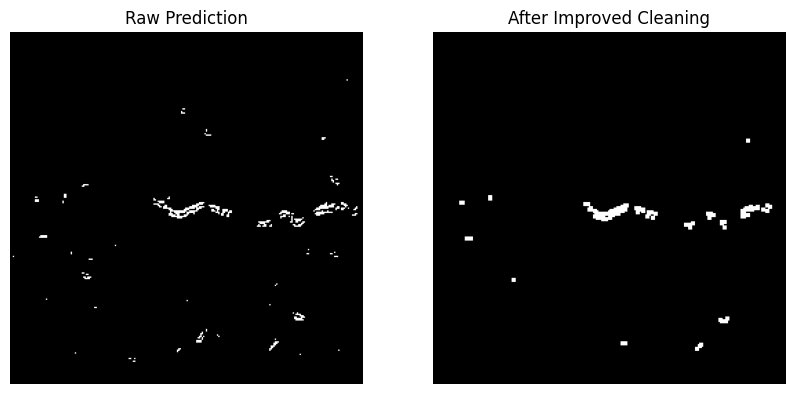

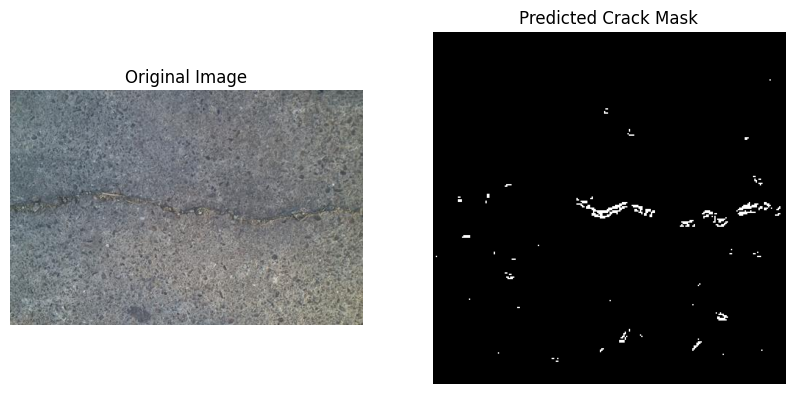

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

#Load your trained model
unet = load_model("/content/unet_crack_segmentation.keras")

#Load and preprocess one test image
test_path = "/content/CrackForest-dataset/image/055.jpg"   # change this path
img = cv2.imread(test_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize to same size as training
img_resized = cv2.resize(img_rgb, (256, 256))
img_norm = img_resized / 255.0

#Predict crack mask
pred = unet.predict(np.expand_dims(img_norm, axis=0))
mask_pred = (pred[0] > 0.22).astype(np.uint8)

# Use a smaller kernel — avoid deleting real cracks
kernel = np.ones((2, 2), np.uint8)

# Light opening to remove specks
mask_clean = cv2.morphologyEx(mask_pred, cv2.MORPH_OPEN, kernel, iterations=1)

# Light dilation to reconnect crack lines
mask_clean = cv2.dilate(mask_clean, kernel, iterations=1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Raw Prediction")
plt.imshow(mask_pred.squeeze(), cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After Improved Cleaning")
plt.imshow(mask_clean.squeeze(), cmap='gray')
plt.axis("off")
plt.show()

#Display result
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Predicted Crack Mask")
plt.imshow(mask_pred.squeeze(), cmap='gray')
plt.axis("off")
plt.show()
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Raw Prediction")
plt.imshow(mask_pred.squeeze(), cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After Improved Cleaning")
plt.imshow(mask_clean.squeeze(), cmap='gray')
plt.axis("off")
plt.show()